# Shape HG information-to-dimension — channel selection + low-N model

**Qquestion.** Can HG decoding be improved by removing noisy channel dimensions and/or using a classifier better suited to the low-N / high-dimensional regime (n_train ≈ 16, p up to 80)? HG-only — no log-HG, no modified smoothing (that would confound this experiment).

**Factors**

| channel strategy | classifier |
|---|---|
| All sampled channels | Linear SVM (C=0.1) — baseline |
| training-only Top-10 / Top-20 / Top-30 (ANOVA F) | Shrinkage LDA (`lsqr`, `shrinkage="auto"`) |
| | L2 Logistic Regression (secondary) |

**Primary comparison: Linear SVM vs Shrinkage LDA.**

**Leakage-free channel selection.** For every SLOO training fold, channels are ranked by univariate ANOVA F-score (`f_classif`) on the training features averaged over the post-fixation window `(1.0 s, end)`; the top-K indices are then
applied to every time bin and to the window scores of that fold. Test labels never influence the ranking (`scripts/spectral_exp.run_channel_select_condition`).


In [1]:
import sys, warnings, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

ROOT = Path.cwd()
REPO = ROOT if (ROOT / "scripts" / "seeg_io.py").exists() else ROOT.parent
sys.path.insert(0, str(REPO / "scripts"))

from seeg_io import SEEGDataset
from decoding import _svm, HIGH_GAMMA_HZ, sloo_folds
from spectral_exp import (
    viable_region_pool, build_hg_tensors, run_condition, run_channel_select_condition,
    viz_smooth, region_diff, summary_row,
    SPATIAL_CUE_WINDOW, SPATIAL_DELAY_WINDOW, SHAPE_CUE_WINDOW, SHAPE_DELAY_WINDOW,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------------ configuration
TASK          = "shape"
DATA_FILE     = "Prefrontal_MNM_Session.mat"
N_CLASSES     = 8
CHANCE        = 1.0 / N_CLASSES
CUE_WINDOW    = SHAPE_CUE_WINDOW
DELAY_WINDOW  = SHAPE_DELAY_WINDOW

REF                 = "Laplacian"
N_TRIALS_PER_CLASS  = 3
FREQ_BAND           = HIGH_GAMMA_HZ            # (70, 150) Hz  -- fixed, HG-only
ENV_LPF_HZ          = 10.0                     # envelope low-pass inside high_gamma_envelope (unchanged)
DOWNSAMPLE          = 20
C_SVM               = 0.1
N_CV_REPEATS        = 5                        # SLOO folds = 3/class x 5 = 15
N_RESAMPLES         = 10
N_CHANNELS          = 80
REGIONS             = ["Dorsal", "Ventral"]
SEED                = 0                        # channel-subsample seed, trial-selection seed, CV-fold seed all derived from this

ds = SEEGDataset(REPO / "data" / DATA_FILE)
FS = ds.fs
BASELINE_SMOOTH_MS  = 488.0                    # current project baseline (build_pseudopopulation default)
BASELINE_SMOOTH_WIN = max(1, int(round(BASELINE_SMOOTH_MS / 1000.0 * FS)))
EFF_TIME_STEP_MS    = DOWNSAMPLE / FS * 1000.0
POOLS = {r: viable_region_pool(ds, r, required_classes=N_CLASSES) for r in REGIONS}

print("=" * 64)
print("CONFIGURATION")
print("=" * 64)
for k, v in [
    ("Task", TASK), ("Data file", DATA_FILE), ("Reference", REF),
    ("Classes", N_CLASSES), ("Chance level", f"{CHANCE:.4f}"),
    ("Trials per class", N_TRIALS_PER_CLASS),
    ("Frequency band (Hz)", FREQ_BAND), ("HG transform", "see experiment"),
    ("Envelope low-pass (Hz)", ENV_LPF_HZ),
    ("Baseline moving-average", f"{BASELINE_SMOOTH_MS:.0f} ms  ({BASELINE_SMOOTH_WIN} samples @ {FS:.0f} Hz)"),
    ("z-score / baseline window", "0.25-0.75 s fixation (build_pseudopopulation default)"),
    ("Downsample factor", DOWNSAMPLE),
    ("Effective time step", f"{EFF_TIME_STEP_MS:.1f} ms"),
    ("Classifier(s)", f"see experiment (Linear SVM C={C_SVM:.2f} baseline)"),
    ("Cross-validation", "Stratified Leave-One-Per-Class-Out (SLOO)"),
    ("CV repeats", N_CV_REPEATS),
    ("SLOO folds", N_CLASSES * 0 + N_TRIALS_PER_CLASS * N_CV_REPEATS),
    ("Channels per subsample", N_CHANNELS),
    ("Channel resamples", N_RESAMPLES),
    ("Seeds (channel / trial / CV)", f"all derived from SEED={SEED}"),
    ("cue window (s)", CUE_WINDOW), ("delay window (s)", DELAY_WINDOW),
]:
    print(f"  {k:32s}: {v}")
for r in REGIONS:
    print(f"  {'viable channels ' + r:32s}: {len(POOLS[r])}")
print("\nNOTE: windows are APPROXIMATE (no epoch markers in the file). "
      "Pseudo-population rows are class-matched population vectors, NOT "
      "simultaneously recorded multichannel trials -> no CSP / Riemannian / connectivity.")


CONFIGURATION
  Task                            : shape
  Data file                       : Prefrontal_MNM_Session.mat
  Reference                       : Laplacian
  Classes                         : 8
  Chance level                    : 0.1250
  Trials per class                : 3
  Frequency band (Hz)             : (70.0, 150.0)
  HG transform                    : see experiment
  Envelope low-pass (Hz)          : 10.0
  Baseline moving-average         : 488 ms  (250 samples @ 512 Hz)
  z-score / baseline window       : 0.25-0.75 s fixation (build_pseudopopulation default)
  Downsample factor               : 20
  Effective time step             : 39.1 ms
  Classifier(s)                   : see experiment (Linear SVM C=0.10 baseline)
  Cross-validation                : Stratified Leave-One-Per-Class-Out (SLOO)
  CV repeats                      : 5
  SLOO folds                      : 15
  Channels per subsample          : 80
  Channel resamples               : 10
  Seeds (channel / tr

In [2]:
# ------------------------------------------------------------------- QC / sanity
def qc_tensor(pop, label):
    X, y = pop.X, pop.y
    issues = []
    if not np.isfinite(X).all():
        issues.append(f"{(~np.isfinite(X)).sum()} non-finite values")
    per_class = np.bincount(y)[np.bincount(y) > 0]
    if not np.all(per_class == N_TRIALS_PER_CLASS):
        issues.append(f"class counts {per_class.tolist()} != {N_TRIALS_PER_CLASS}")
    if int(np.unique(y).size) != N_CLASSES:
        issues.append(f"{np.unique(y).size} classes present, expected {N_CLASSES}")
    if abs(pop.chance - CHANCE) > 1e-9:
        issues.append(f"chance {pop.chance} != {CHANCE}")
    n_train = X.shape[0] - N_CLASSES
    tag = "OK" if not issues else "FAIL: " + "; ".join(issues)
    print(f"  {label:28s} X{X.shape}  n_train/fold={n_train}  p/n_train={X.shape[1]/n_train:.2f}  {tag}")
    assert not issues, f"QC failed for {label}: {issues}"

def check_paired(a, b, label):
    ok = (np.array_equal(a.y, b.y) and np.array_equal(a.time_s, b.time_s)
          and a.channel_indices == b.channel_indices)
    print(f"  paired [{label}]: y/time/channels identical = {ok}")
    assert ok, f"paired comparison violated for {label}"


In [3]:
# ----------------------------------------------------- channel strategies / models
K_VALUES = [10, 20, 30]                       # + "All"
RANK_WINDOW = None                            # set after we know the time axis (post-fixation to end)

def svm():    return _svm(C_SVM)
def lda():    return make_pipeline(StandardScaler(),
                                  LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
def logreg(): return make_pipeline(StandardScaler(),
                                  LogisticRegression(C=C_SVM, penalty="l2", solver="lbfgs", max_iter=400))

CLASSIFIERS = {"Linear SVM": svm, "Shrinkage LDA": lda}          # primary
SECONDARY   = {"L2 LogReg": logreg}                              # secondary, All + Top-20 only


In [4]:
# ------------------------------------------------------- computational cost
_probe = build_hg_tensors(ds, POOLS["Dorsal"], n_resamples=1, n_channels=N_CHANNELS,
                          ref=REF, downsample=DOWNSAMPLE, seed=SEED)[0]
N_BINS  = _probe.X.shape[2]
N_FOLDS = N_TRIALS_PER_CLASS * N_CV_REPEATS
N_COND  = (1 + len(K_VALUES)) * len(CLASSIFIERS) + 2
approx_fits = len(REGIONS) * N_COND * N_RESAMPLES * (N_BINS * N_FOLDS + 2 * N_FOLDS)
print(f"regions={len(REGIONS)}  conditions={N_COND}  resamples={N_RESAMPLES}  "
      f"time-bins={N_BINS}  SLOO-folds={N_FOLDS}")
print(f"approx model fits (full run): {approx_fits:,}")
print(f"K values: {K_VALUES} + All;  primary classifiers: {list(CLASSIFIERS)};  secondary: {list(SECONDARY)} (All + Top-20 only)")


regions=2  conditions=10  resamples=10  time-bins=244  SLOO-folds=15
approx model fits (full run): 738,000
K values: [10, 20, 30] + All;  primary classifiers: ['Linear SVM', 'Shrinkage LDA'];  secondary: ['L2 LogReg'] (All + Top-20 only)


## Smoke test (tiny config — NOT final results)

In [5]:
T = build_hg_tensors(ds, POOLS["Dorsal"], n_resamples=2, n_channels=50, ref=REF,
                    downsample=40, seed=SEED)
end = float(T[0].time_s[-1]); rw = (1.0, end)
for cname, fac in CLASSIFIERS.items():
    for K in [None, 20]:
        d = run_channel_select_condition(T, fac, K=K, rank_window=rw, n_cv_repeats=2,
                                         cue_window=CUE_WINDOW, delay_window=DELAY_WINDOW)
        print(f"  {cname:14s} K={str(d['K']):>4s}  delay={d['delay_mean']:.3f}  peak={d['peak_mean']:.3f}")
print("smoke OK")


  Linear SVM     K=None  delay=0.260  peak=0.354


  Linear SVM     K=  20  delay=0.125  peak=0.312


  Shrinkage LDA  K=None  delay=0.115  peak=0.354


  Shrinkage LDA  K=  20  delay=0.104  peak=0.281
smoke OK


## Full run

In [6]:
RES = {}     # RES[region][(classifier, strategy)] -> result
SEL = {}     # RES selection-frequency for Top-K
t0 = time.time()
for reg in REGIONS:
    RES[reg], SEL[reg] = {}, {}
    T = build_hg_tensors(ds, POOLS[reg], n_resamples=N_RESAMPLES, n_channels=N_CHANNELS,
                         ref=REF, downsample=DOWNSAMPLE, seed=SEED)
    qc_tensor(T[0], reg)
    end = float(T[0].time_s[-1]); rw = (1.0, end)
    n_ch = T[0].X.shape[1]
    ks = [None] + [k for k in K_VALUES if k < n_ch]
    for cname, fac in CLASSIFIERS.items():
        for K in ks:
            key = (cname, "All" if K is None else f"Top-{K}")
            d = run_channel_select_condition(T, fac, K=K, rank_window=rw, n_cv_repeats=N_CV_REPEATS,
                                             cue_window=CUE_WINDOW, delay_window=DELAY_WINDOW,
                                             collect_selected=(K is not None and cname == "Linear SVM"))
            RES[reg][key] = d
            if "selection_freq" in d:
                SEL[reg][key] = d["selection_freq"]
    # secondary: LogReg, All + Top-20 only
    for K in [None, 20]:
        if K is not None and K >= n_ch:
            continue
        key = ("L2 LogReg", "All" if K is None else f"Top-{K}")
        RES[reg][key] = run_channel_select_condition(T, logreg, K=K, rank_window=rw,
                                                     n_cv_repeats=N_CV_REPEATS,
                                                     cue_window=CUE_WINDOW, delay_window=DELAY_WINDOW)
    print(f"  {reg}: {len(RES[reg])} conditions, {time.time() - t0:.0f}s elapsed")
print(f"full run done in {time.time() - t0:.0f}s")


  Dorsal                       X(24, 78, 244)  n_train/fold=16  p/n_train=4.88  OK


  Dorsal: 10 conditions, 850s elapsed


  Ventral                      X(24, 80, 244)  n_train/fold=16  p/n_train=5.00  OK


  Ventral: 10 conditions, 1695s elapsed
full run done in 1695s


## 3.9 Diagnostics — n_train, dimensionality, selection stability

In [7]:
for reg in REGIONS:
    any_key = next(iter(RES[reg]))
    d = RES[reg][any_key]
    print(f"{reg}: n_train/fold = {d['n_train']}, input channels = {N_CHANNELS} "
          f"(pool {len(POOLS[reg])})")
    for (cname, strat), r in RES[reg].items():
        if cname != "Linear SVM":
            continue
        print(f"  {strat:8s}  K={str(r['K']):>4s}  p/n_train = {r['p_over_n']:.2f}")

# how often each channel is picked (Linear SVM Top-20), top 12 per region
for reg in REGIONS:
    freq = SEL[reg].get(("Linear SVM", "Top-20"), {})
    if freq:
        top = list(freq.items())[:12]
        print(f"\n{reg} — Top-20 channel selection frequency (Linear SVM), most-picked 12:")
        print("  " + "  ".join(f"ch{c}:{p:.2f}" for c, p in top))
print("\n(selection frequency is descriptive only — not anatomical significance)")


Dorsal: n_train/fold = 16, input channels = 80 (pool 115)
  All       K=None  p/n_train = 4.88
  Top-10    K=  10  p/n_train = 0.62
  Top-20    K=  20  p/n_train = 1.25
  Top-30    K=  30  p/n_train = 1.88
Ventral: n_train/fold = 16, input channels = 80 (pool 141)
  All       K=None  p/n_train = 5.00
  Top-10    K=  10  p/n_train = 0.62
  Top-20    K=  20  p/n_train = 1.25
  Top-30    K=  30  p/n_train = 1.88

Dorsal — Top-20 channel selection frequency (Linear SVM), most-picked 12:
  ch452:0.48  ch453:0.38  ch454:0.37  ch483:0.34  ch395:0.33  ch392:0.33  ch283:0.32  ch481:0.32  ch471:0.31  ch281:0.31  ch455:0.31  ch495:0.30

Ventral — Top-20 channel selection frequency (Linear SVM), most-picked 12:
  ch445:0.45  ch278:0.37  ch277:0.35  ch398:0.32  ch447:0.31  ch397:0.31  ch449:0.30  ch446:0.29  ch274:0.28  ch467:0.25  ch319:0.25  ch333:0.25

(selection frequency is descriptive only — not anatomical significance)


## Time-resolved decoding — classifier × channel strategy

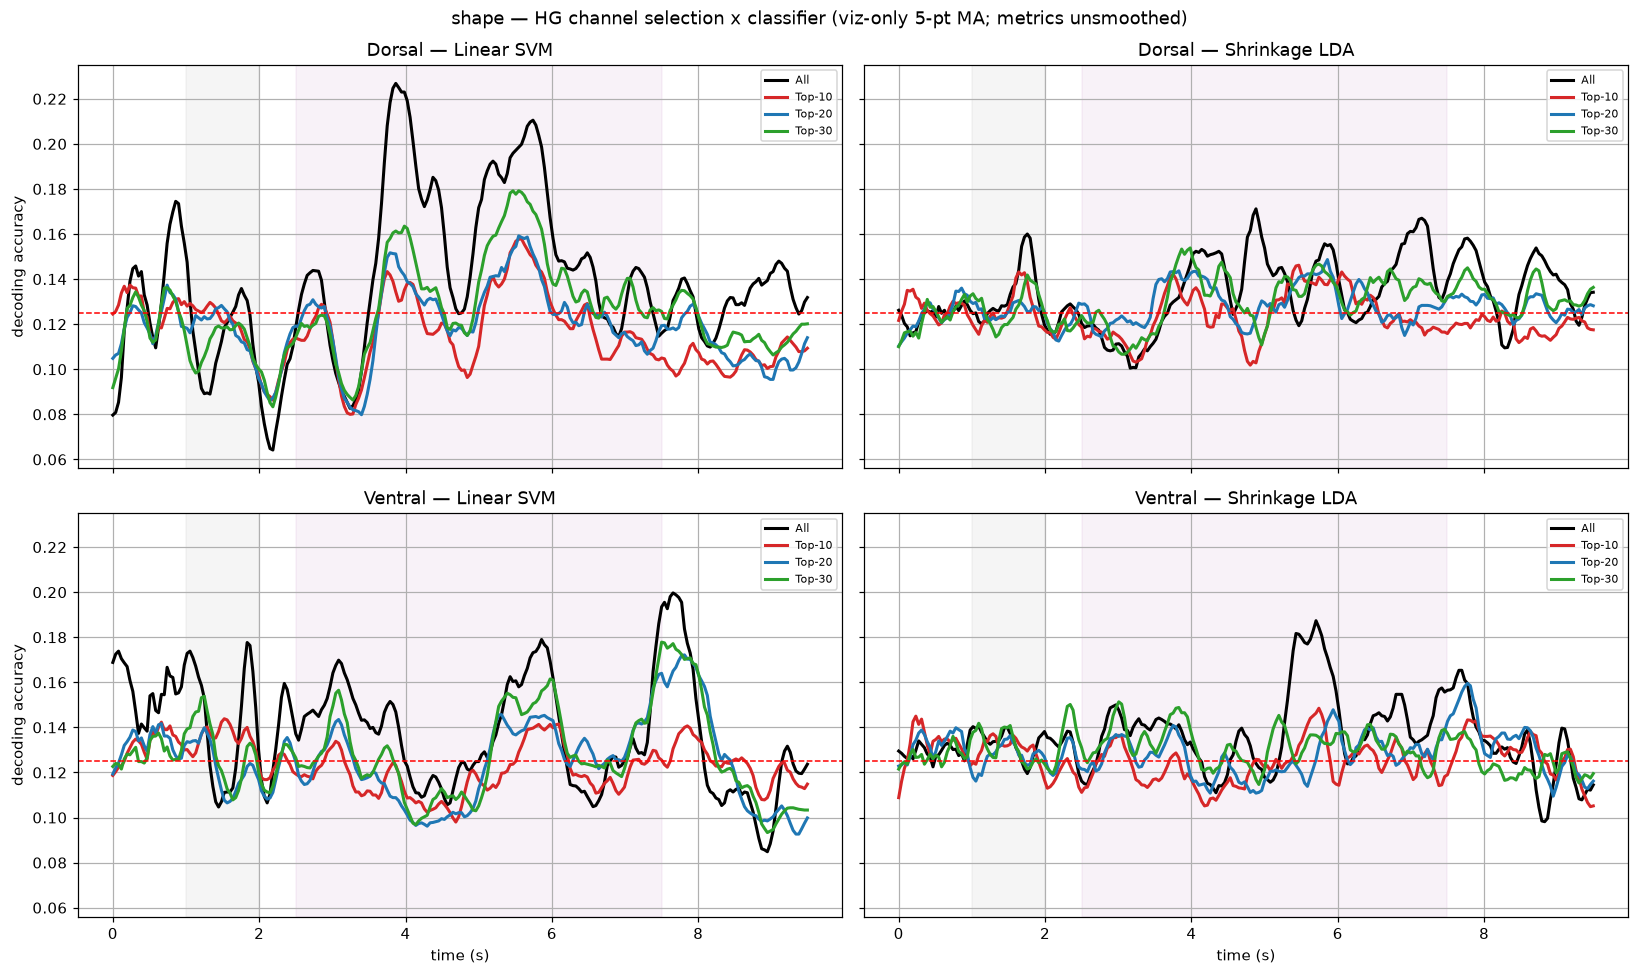

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=True)
strat_col = {"All": "k", "Top-10": "tab:red", "Top-20": "tab:blue", "Top-30": "tab:green"}
for i, reg in enumerate(REGIONS):
    for j, cname in enumerate(CLASSIFIERS):
        ax = axes[i][j]
        for (cn, strat), d in RES[reg].items():
            if cn != cname:
                continue
            m, se = viz_smooth(d["curves"], 5)
            ax.plot(d["time_s"], m, color=strat_col.get(strat, "grey"), lw=2, label=strat)
        ax.axhline(CHANCE, color="red", ls="--", lw=1)
        ax.axvspan(*CUE_WINDOW, color="grey", alpha=0.08)
        ax.axvspan(*DELAY_WINDOW, color="purple", alpha=0.05)
        ax.set_title(f"{reg} — {cname}")
        if i == 1: ax.set_xlabel("time (s)")
        if j == 0: ax.set_ylabel("decoding accuracy")
        ax.legend(fontsize=7)
fig.suptitle(f"{TASK} — HG channel selection x classifier (viz-only 5-pt MA; metrics unsmoothed)")
plt.tight_layout()


**Findings**
- Shape-related HG information appears relatively distributed across channels in both dorsal and ventral PFC, because aggressive Top-K channel selection generally reduces rather than improves decoding.
- Shrinkage LDA reduces the large fluctuations seen with all-channel SVM, but this stabilization comes with no clear gain in mean decoding performance.

## Summary table

`Task | Region | Classifier | Channel Strategy | K | Peak Accuracy | Peak Time | Delay Mean | Delay Peak`

In [9]:
print(f"{'Task':8s} {'Region':8s} {'Classifier':14s} {'Strategy':9s} {'K':>4s} "
      f"{'PeakAcc':>8s} {'PeakT':>7s} {'DelayMean':>10s} {'DelayPeak':>10s} {'DelaySD':>8s}")
for reg in REGIONS:
    for (cname, strat), d in RES[reg].items():
        print(f"{TASK:8s} {reg:8s} {cname:14s} {strat:9s} {str(d['K']):>4s} "
              f"{d['peak_mean']:8.3f} {d['peak_t_mean']:7.2f} {d['delay_mean']:10.3f} "
              f"{d['delay_peak_mean']:10.3f} {d['delay_std']:8.3f}")

print("\ndescriptive Dorsal - Ventral (delay window, NOT significance):")
for (cname, strat) in RES["Dorsal"]:
    if (cname, strat) in RES["Ventral"]:
        rd = region_diff(RES["Dorsal"][(cname, strat)], RES["Ventral"][(cname, strat)])
        print(f"  {cname:14s} {strat:9s}  cue D-V={rd['cue_diff']:+.3f}  delay D-V={rd['delay_diff']:+.3f}")


Task     Region   Classifier     Strategy     K  PeakAcc   PeakT  DelayMean  DelayPeak  DelaySD
shape    Dorsal   Linear SVM     All       None    0.328    3.63      0.172      0.312    0.050
shape    Dorsal   Linear SVM     Top-10      10    0.230    3.16      0.128      0.213    0.032
shape    Dorsal   Linear SVM     Top-20      20    0.231    3.39      0.130      0.221    0.029
shape    Dorsal   Linear SVM     Top-30      30    0.251    4.11      0.134      0.248    0.049
shape    Dorsal   Shrinkage LDA  All       None    0.285    5.07      0.142      0.253    0.040
shape    Dorsal   Shrinkage LDA  Top-10      10    0.218    3.58      0.132      0.212    0.024
shape    Dorsal   Shrinkage LDA  Top-20      20    0.231    5.23      0.120      0.220    0.041
shape    Dorsal   Shrinkage LDA  Top-30      30    0.229    5.11      0.126      0.223    0.044
shape    Dorsal   L2 LogReg      All       None    0.337    5.11      0.171      0.319    0.047
shape    Dorsal   L2 LogReg      Top-20 